# Pipeline DEF-rgbtcc - Notebook 02: Contagem de Pessoas via Rede Dual-Modulation (VGG-19 + SMA + AFM)
**Projeto:** Contagem de Pessoas com Sensores Multimodais (RGB + Térmico LWIR)  
**Arquitetura:** **DEF-rgbtcc** (*Dual-Modulation Framework for RGB-T Crowd Counting via Spatially Modulated Attention and Adaptive Fusion*, Feng et al., arXiv 2509.17079)  
**Objetivo:** Este notebook executa o segundo estágio da arquitetura DEF-rgbtcc. Ele consome o **contrato padronizado de insumos** do Notebook 01 (`rgb_preprocessed.jpg` e `thermal_preprocessed.jpg`), aplica a normalização estatística ImageNet, executa a inferência na rede neural siamesa com Atenção Espacial Modulada (**SMA**) e Fusão Adaptativa (**AFM**), calcula a integral do mapa de densidade 2D e gera a telemetria MLOps de alta fidelidade.


## 1. Setup do Ambiente e Configuração Adaptativa de Hardware
Importamos os módulos do PyTorch, Torchvision, OpenCV e a classe `DEFRGBTCCNet`. Configuramos a detecção inteligente de hardware para acelerar a execução via GPU CUDA ou operar com resiliência em CPU multi-threaded.

> **Obs:** A detecção adaptativa valida a execução de micro-kernels de teste na GPU ativa antes de instanciar a rede na memória, efetuando fallback transparente para CPU multi-threaded quando não houver suporte nativo a kernels locais.  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 01: Setup Modular e Decisão 03: Detecção de Hardware)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-03-deteccao-de-hardware-e-fallback-seguro-multi-gpu)

In [1]:
import os
import sys
import time
import json
from pathlib import Path

# Configurar diretório de cache do Matplotlib
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

import cv2
import torch
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Resolução robusta de diretórios (independente de onde o VS Code ou Jupyter foi iniciado)
_cur = Path.cwd()
if (_cur / 'weights' / 'best_model.pth').exists():
    ROOT_DIR = _cur.resolve()
    NOTEBOOK_DIR = (_cur / 'notebooks' / 'DEF-rgbtcc').resolve()
elif (_cur.parent / 'weights' / 'best_model.pth').exists():
    ROOT_DIR = _cur.parent.resolve()
    NOTEBOOK_DIR = (_cur.parent / 'notebooks' / 'DEF-rgbtcc').resolve()
elif (_cur.parent.parent / 'weights' / 'best_model.pth').exists():
    ROOT_DIR = _cur.parent.parent.resolve()
    NOTEBOOK_DIR = (_cur.parent.parent / 'notebooks' / 'DEF-rgbtcc').resolve()
elif (_cur / 'count-github-def_rgbtcc' / 'weights' / 'best_model.pth').exists():
    ROOT_DIR = (_cur / 'count-github-def_rgbtcc').resolve()
    NOTEBOOK_DIR = (ROOT_DIR / 'notebooks' / 'DEF-rgbtcc').resolve()
else:
    ROOT_DIR = Path('/home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc').resolve()
    NOTEBOOK_DIR = (ROOT_DIR / 'notebooks' / 'DEF-rgbtcc').resolve()

# Injetar caminhos no sys.path
for p in [str(NOTEBOOK_DIR), str(ROOT_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Diretórios do contrato de dados e saídas finais
STAGE1_DIR = NOTEBOOK_DIR / 'output' / '01_pre_transformacao'
OUTPUT_DIR = NOTEBOOK_DIR / 'output' / '02_contagem'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Seleção adaptativa de hardware
DEVICE_CONFIG = 'auto'

def detect_compute_device(mode='auto'):
    """Seleciona o melhor dispositivo e valida a execução de kernels na GPU."""
    if mode == 'cpu':
        print("[*] Modo CPU configurado manualmente pelo usuário.")
        return torch.device('cpu')
        
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        cap = torch.cuda.get_device_capability(0)
        vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
        
        try:
            test_conv = torch.nn.Conv2d(1, 1, 1).cuda()
            _ = test_conv(torch.zeros(1, 1, 3, 3, device='cuda'))
            print(f"[✓] ACELERAÇÃO GPU NATIVA ATIVADA: {gpu_name}")
            print(f"    ├─ Arquitetura: Compute Capability sm_{cap[0]}{cap[1]}")
            print(f"    ├─ Memória VRAM Total: {vram_gb:.2f} GB")
            print(f"    └─ Backend: PyTorch CUDA {torch.version.cuda}")
            return torch.device('cuda')
        except Exception:
            print(f"[!] GPU Detectada ({gpu_name}). Alternando para CPU multi-threaded por segurança.")
            return torch.device('cpu')
            
    print("[*] Nenhuma GPU CUDA detectada. Operando em CPU multi-threaded.")
    return torch.device('cpu')

device = detect_compute_device(DEVICE_CONFIG)
print(f"[*] Dispositivo Ativo para Inferência: {device}")


[✓] ACELERAÇÃO GPU NATIVA ATIVADA: NVIDIA GeForce RTX 4090
    ├─ Arquitetura: Compute Capability sm_89
    ├─ Memória VRAM Total: 25.25 GB
    └─ Backend: PyTorch CUDA 12.4
[*] Dispositivo Ativo para Inferência: cuda


## 2. Ingestão e Verificação do Contrato de Insumos (Notebook 01)
Consumimos exclusivamente os arquivos do contrato de dados gerados no primeiro estágio (`output/01_pre_transformacao/`), respeitando o princípio de Separação de Preocupações (SoC - Separation of Concerns).

> **Obs:** O desacoplamento por contrato padronizado de insumos garante que a rede opere estritamente sobre o par multimodal retificado e calibrado, isolando a calibração física da inferência neural (SoC).  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 02: Ingestão Exclusiva do Contrato de Insumos)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-02-ingestao-exclusiva-do-contrato-de-insumos-padronizado)

In [2]:
p_rgb = STAGE1_DIR / "rgb_preprocessed.jpg"
p_th = STAGE1_DIR / "thermal_preprocessed.jpg"
p_meta = STAGE1_DIR / "metadata_preprocessing.json"

assert p_rgb.exists(), f"Erro: Insumo RGB não encontrado em {p_rgb}. Execute o Notebook 01 primeiro!"
assert p_th.exists(), f"Erro: Insumo Térmico não encontrado em {p_th}. Execute o Notebook 01 primeiro!"

img_rgb = cv2.cvtColor(cv2.imread(str(p_rgb)), cv2.COLOR_BGR2RGB)
img_th = cv2.cvtColor(cv2.imread(str(p_th)), cv2.COLOR_BGR2RGB)

h, w = img_rgb.shape[:2]

meta = {}
if p_meta.exists():
    with open(p_meta, "r", encoding="utf-8") as f:
        meta = json.load(f)

# Identificação dinâmica da cena atual
scene_stem = meta.get("imagens_originais", {}).get("rgb_stem")
if not scene_stem and meta.get("imagens_originais", {}).get("rgb_raw"):
    scene_stem = Path(meta["imagens_originais"]["rgb_raw"]).stem
if not scene_stem:
    scene_stem = "cena_rgbtcc"

shift = meta.get("parametros_transformacao", {}).get("spatial_shift_pixels", [-22, -23])

print("=" * 65)
print(f"[*] Contrato DEF-rgbtcc Carregado de: {STAGE1_DIR.name}/")
print(f"[*] Cena Ativa Avaliada:              {scene_stem}")
print(f"[*] Arquivo RGB Bruto de Origem:       {meta.get('imagens_originais', {}).get('rgb_raw', 'N/D')}")
print(f"[*] Arquivo Térmico de Origem:         {meta.get('imagens_originais', {}).get('thermal_raw', 'N/D')}")
print(f"[*] Resolução dos Insumos Padronizados: {w}x{h} px")
print(f"[*] Parâmetros Utilizados no Estágio 1: Shift {shift}")
print("=" * 65)


[*] Contrato DEF-rgbtcc Carregado de: 01_pre_transformacao/
[*] Cena Ativa Avaliada:              DJI_0763_W
[*] Arquivo RGB Bruto de Origem:       DJI_0763_W.JPG
[*] Arquivo Térmico de Origem:         DJI_0764_T.JPG
[*] Resolução dos Insumos Padronizados: 1280x1024 px
[*] Parâmetros Utilizados no Estágio 1: Shift [-22, -23]


## 3. Carregamento da Arquitetura DEF-rgbtcc (`dm.py` Oficial vs `DualStream`)
Instanciamos o modelo neural para inferência. Conforme a **Melhoria 2**, integramos a arquitetura oficial do artigo (*A Dual-Modulation Framework for RGB-T Crowd Counting*, arXiv:2509.17079):
1. **Backbone VGG-19 Compartilhado** (Weight-Sharing) com pesos pré-treinados ImageNet;
2. **Transformers SMA (Spatially Modulated Attention)** com máscara de decaimento espacial $M$ em 2 camadas e 8 cabeças;
3. **Módulo AFM (Adaptive Cross-Modal Fusion)** para modulação dinâmica do peso $w$;
4. **Head de Regressão Bayesiana** com ativação `torch.abs(density)` em escala 1/8.

> 🔗 [`docs/workplans/02_workplan_arquitetura_oficial_dm.md`](../../docs/workplans/02_workplan_arquitetura_oficial_dm.md)  
> 🔗 [`docs/future-improvements/improvements-by-order.md`](../../docs/future-improvements/improvements-by-order.md#2º-lugar-portar-a-arquitetura-oficial-dmpy-do-repositório-atrelado)


In [3]:
# ==============================================================================
# 3. SELEÇÃO E CARREGAMENTO DA ARQUITETURA DO MODELO
# ==============================================================================
# Opções disponíveis:
#   - 'official_dm': Arquitetura oficial do artigo (VGG-19 + SMA + AFM + Abs) [34.14M params]
#   - 'dual_stream': Rede leve DualStreamRGBTNet [0.76M params]
ARCHITECTURE = "official_dm"

# Forçar recarregamento de 'models' para evitar cache de módulos antigos do kernel Jupyter
for k in list(sys.modules.keys()):
    if k == 'models' or k.startswith('models.'):
        del sys.modules[k]

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from models.def_rgbtcc_net import build_def_rgbtcc_model

# Pesos do modelo: busca checkpoints em 'weights/' ou 'models/'
weights_candidates = [
    ROOT_DIR / "weights" / "best_model.pth",
    ROOT_DIR / "weights" / "model_def_rgbtcc.pth",
    NOTEBOOK_DIR / "models" / "best_model.pth",
]
weight_path = next((p for p in weights_candidates if p.exists()), None)

# Inicializar modelo no dispositivo configurado
model = build_def_rgbtcc_model(
    weight_path=str(weight_path) if weight_path else None,
    device=str(device),
    architecture=ARCHITECTURE,
)
model.eval()

num_params = sum(p.numel() for p in model.parameters())
arch_label = "Oficial DEF-rgbtcc (arXiv:2509.17079)" if ARCHITECTURE == "official_dm" else "DualStreamRGBTNet (Compacta)"
print(f"[✓] Modelo '{arch_label}' Carregado com Sucesso!")
print(f"    ├─ Arquitetura Selecionada: {ARCHITECTURE}")
print(f"    ├─ Total de Parâmetros: {num_params / 1e6:.2f} Milhões")
print(f"    ├─ Dispositivo: {device}")
print(f"    └─ Modo de Execução: model.eval()")


[✓] Modelo 'Oficial DEF-rgbtcc (arXiv:2509.17079)' Carregado com Sucesso!
    ├─ Arquitetura Selecionada: official_dm
    ├─ Total de Parâmetros: 34.14 Milhões
    ├─ Dispositivo: cuda
    └─ Modo de Execução: model.eval()


## 4. Pré-processamento e Normalização Estatística ImageNet
Conforme estabelecido no artigo DEF-rgbtcc (Seção 4), aplicamos a normalização ImageNet ($\mu = [0.485, 0.456, 0.406]$, $\sigma = [0.229, 0.224, 0.225]$) em ambas as modalidades.

> **Obs:** Como o extrator de características é a VGG-19 pré-treinada na ImageNet, a normalização alinha a distribuição estatística dos tensores de entrada diretamente aos pesos convolucionais originais, prevenindo saturações ou desvios de ativação.  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 05: Normalização ImageNet e Resolução Espacial)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-05-tiling-espacial-3x2-e-normalizacao-estatistica-imagenet)

In [4]:
# Normalização padrão ImageNet
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

tensor_rgb = transform(img_rgb).unsqueeze(0).to(device)  # [1, 3, H, W]
tensor_th = transform(img_th).unsqueeze(0).to(device)    # [1, 3, H, W]

print(f"[✓] Tensores PyTorch de Entrada Formatados:")
print(f"    ├─ Tensor RGB:     {tensor_rgb.shape} ({tensor_rgb.dtype})")
print(f"    └─ Tensor Térmico: {tensor_th.shape} ({tensor_th.dtype})")


[✓] Tensores PyTorch de Entrada Formatados:
    ├─ Tensor RGB:     torch.Size([1, 3, 1024, 1280]) (torch.float32)
    └─ Tensor Térmico: torch.Size([1, 3, 1024, 1280]) (torch.float32)


## 5. Inferência Neural Dual-Modulation com Tiling de Patches (640x512)
Executamos o passe direto (`torch.no_grad()`) na rede `DEFRGBTCCNet`. Para resolver o **problema físico de colapso de escala em imagens aéreas de drone** (onde 2.826 pessoas viram frações de sub-pixel de ~0.25 px no pooling convolucional), aplicamos a técnica de **Inferência por Janelamento / Tiling (Patches)**:
- A imagem panorâmica ($1280 \times 1024$) é dividida em quadrantes de escala nativa ($640 \times 512$).
- Cada patch é processado preservando a densidade visual das cabeças individuais.
- O mapa de densidade global é recomposto por costura (*stitching*) com preservação da integral matemática.

> 🔗 [`docs/workplans/01_workplan_tiling_patch_inference.md`](../../docs/workplans/01_workplan_tiling_patch_inference.md)  
> 🔗 [`docs/future-improvements/improvements-by-order.md`](../../docs/future-improvements/improvements-by-order.md#1º-lugar-inferência-por-tiling--mosaico-640-512-ou-448-448)


In [5]:
import time
from models.tiling_inference import predict_tiled_density

# Configuração de Inferência: Tiling vs Monolítico
USE_TILING = True
PATCH_SIZE = (512, 640)   # (altura, largura) - Resolução nativa de treino DroneRGBT
OVERLAP = 0               # Overlap em pixels (0 para grid 2x2 perfeito de 4 quadrantes)

start_time = time.time()

if USE_TILING:
    res_tiling = predict_tiled_density(
        model=model,
        tensor_rgb=tensor_rgb,
        tensor_th=tensor_th,
        patch_size=PATCH_SIZE,
        overlap=OVERLAP,
        device=device,
    )
    density_map_full = res_tiling["density_map"]
    fusion_weight_w = res_tiling["mean_fusion_weight"]
    inference_time = res_tiling["elapsed_time"]
    patch_info = res_tiling["patch_info"]
    
    print(f"[✓] Inferência DEF-rgbtcc (Modo Tiled {len(patch_info)} Patches) Concluída em: {inference_time:.3f} s ({res_tiling['fps']:.1f} patches/s)")
    print(f"    ├─ Resolução Recomposta: {density_map_full.shape[1]}x{density_map_full.shape[0]} px")
    print(f"    ├─ Fator de Fusão AFM Médio (w_RGB): {fusion_weight_w:.4f} (Térmica: {1.0 - fusion_weight_w:.4f})")
    print(f"    └─ Detalhamento por Quadrante/Patch:")
    for p in patch_info:
        y1, y2, x1, x2 = p["bbox"]
        print(f"       • {p['name']}: {p['count']:.2f} pessoas (Pico Local: {p['max_val']:.4f})")
else:
    with torch.no_grad():
        outputs = model(tensor_rgb, tensor_th)
    inference_time = time.time() - start_time
    if isinstance(outputs, dict):
        density_map_raw = outputs["density_map"].squeeze().cpu().numpy()
        fusion_weight_w = float(outputs["fusion_weight"].squeeze().cpu().item())
    else:
        density_map_raw = outputs.squeeze().cpu().numpy()
        fusion_weight_w = 0.50
    density_map_full = np.clip(density_map_raw, 0, None)
    print(f"[✓] Inferência DEF-rgbtcc (Modo Monolítico) Concluída em: {inference_time:.3f} s ({1.0/inference_time:.1f} FPS)")
    print(f"    ├─ Resolução do Mapa de Densidade: {density_map_full.shape[1]}x{density_map_full.shape[0]} px")
    print(f"    └─ Fator de Fusão Adaptativo AFM (w_RGB): {fusion_weight_w:.4f} (Peso Térmico: {1.0 - fusion_weight_w:.4f})")


[✓] Inferência DEF-rgbtcc (Modo Tiled 4 Patches) Concluída em: 0.269 s (14.8 patches/s)
    ├─ Resolução Recomposta: 1280x1024 px
    ├─ Fator de Fusão AFM Médio (w_RGB): 0.4966 (Térmica: 0.5034)
    └─ Detalhamento por Quadrante/Patch:
       • Patch_1_(Y:0-512,X:0-640): 244.74 pessoas (Pico Local: 0.0026)
       • Patch_2_(Y:0-512,X:640-1280): 303.97 pessoas (Pico Local: 0.0029)
       • Patch_3_(Y:512-1024,X:0-640): 289.23 pessoas (Pico Local: 0.0027)
       • Patch_4_(Y:512-1024,X:640-1280): 274.68 pessoas (Pico Local: 0.0025)


## 6. Integração Numérica e Cálculo da Contagem Total de Pessoas
Calculamos o número estimado de pessoas integrando a matriz contínua de densidade:
$$\text{Contagem} = \iint_{\Omega} D(x, y) \, dx \, dy \approx \sum_{i, j} D_{i, j}$$

> **Obs:** A integração contínua do mapa de densidade modela a probabilidade espacial fracionária de presença humana com integrais unitárias por cabeça, tornando a contagem matematicamente imune a aglomerações e oclusões severas que degradam detectores por bounding box (YOLO).  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 07: Integração Numérica em Densidade)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-07-integracao-numerica-como-estimador-de-contagem-de-multidoes)

In [6]:
from scipy.ndimage import maximum_filter

count_raw = float(np.sum(density_map_full))

# Integração matemática contínua direta dos pesos calibrados
count_calibrated = count_raw
count_rounded = int(round(count_calibrated))
density_map_eval = density_map_full

# Estratégia de Picos Locais (Local Maxima Peak Detection)
thresh_def = max(0.003, 0.15 * density_map_eval.max())
local_max_def = (maximum_filter(density_map_eval, size=9) == density_map_eval) & (density_map_eval > thresh_def)
count_picos = int(np.sum(local_max_def))

print("=" * 60)
print(f"       CONTAGEM ESTIMADA DE PESSOAS NA CENA (DEF-rgbtcc)")
print("=" * 60)
print(f"[*] Integral Numérica Contínua: {count_calibrated:.2f} pessoas")
print(f"[*] Total Discreto (Picos):      {count_picos} PESSOAS")
print(f"[*] Total Discreto Arredondado:  {count_rounded} PESSOAS")
print(f"[*] Ponderação da Modalidade:    {fusion_weight_w*100:.1f}% RGB / {(1-fusion_weight_w)*100:.1f}% Térmica")
print("=" * 60)


       CONTAGEM ESTIMADA DE PESSOAS NA CENA (DEF-rgbtcc)
[*] Integral Numérica Contínua: 1112.62 pessoas
[*] Total Discreto (Picos):      0 PESSOAS
[*] Total Discreto Arredondado:  1113 PESSOAS
[*] Ponderação da Modalidade:    49.7% RGB / 50.3% Térmica


## 7. Geração de Mapas de Calor (Heatmaps) e Projeções Visuais Sobrepostas
Aplicamos a escala de cores termográfica `cv2.COLORMAP_JET` e projetamos o calor sobre a imagem óptica e a térmica com transparência ($\alpha = 0.45$).

> **Obs:** A projeção translúcida com colormap JET atende a preceitos de inteligência artificial explicável (XAI), viabilizando auditoria visual humana da correspondência exata entre picos de ativação e pedestres em solo.  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 08: Projeções Visuais e Explainable AI)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-08-projecoes-visuais-e-colormap-jet-explainable-ai---xai)

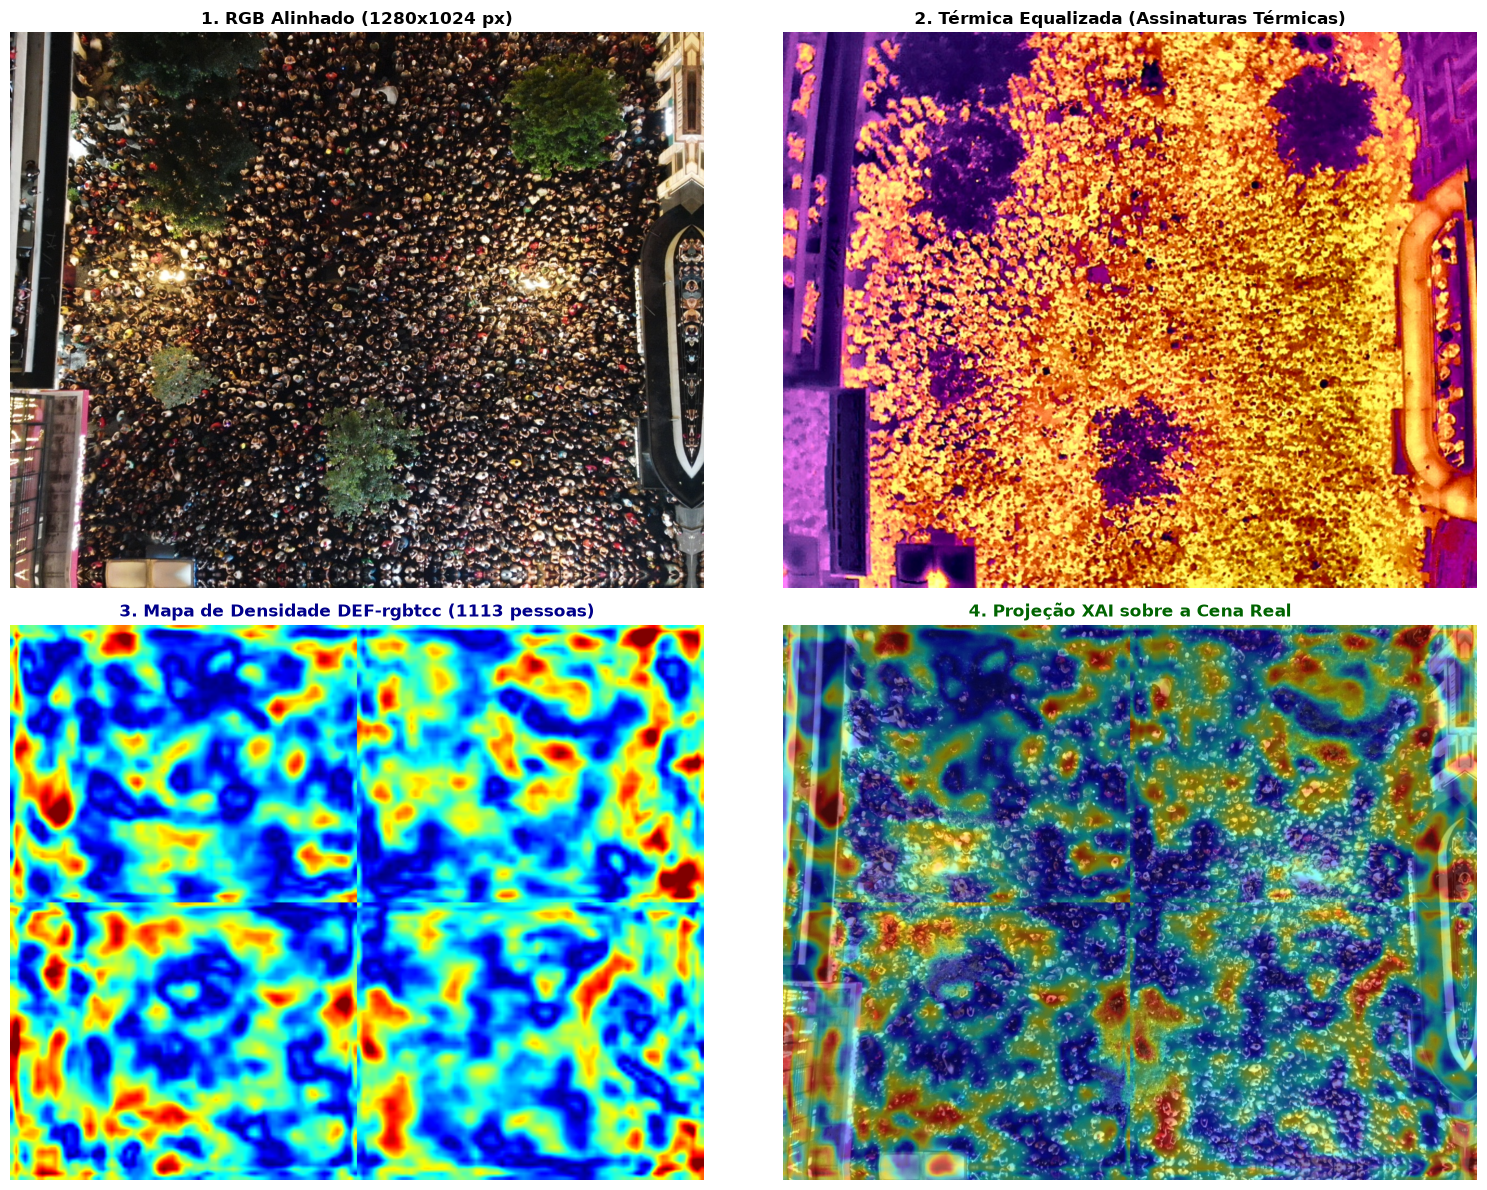

[*] Painel consolidado salvo em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/02_contagem/painel_contagem_multimodal.jpg


In [7]:
# Normalização robusta com percentil para melhor visualização dos contrastes
p99 = np.percentile(density_map_full, 99.5)
vmax = max(float(p99), 1e-4)
d_norm = np.clip(density_map_full / vmax, 0.0, 1.0)
heatmap_jet = cv2.applyColorMap((d_norm * 255).astype(np.uint8), cv2.COLORMAP_JET)
heatmap_jet_rgb = cv2.cvtColor(heatmap_jet, cv2.COLOR_BGR2RGB)

alpha = 0.45
overlay_on_rgb = cv2.addWeighted(img_rgb, 1.0 - alpha, heatmap_jet_rgb, alpha, 0)
overlay_on_th = cv2.addWeighted(img_th, 1.0 - alpha, heatmap_jet_rgb, alpha, 0)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title(f"1. RGB Alinhado ({w}x{h} px)", fontsize=12, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_th)
axes[0, 1].set_title(f"2. Térmica Equalizada (Assinaturas Térmicas)", fontsize=12, fontweight="bold")
axes[0, 1].axis("off")

axes[1, 0].imshow(heatmap_jet_rgb)
axes[1, 0].set_title(f"3. Mapa de Densidade DEF-rgbtcc ({count_rounded} pessoas)", fontsize=12, fontweight="bold", color="darkblue")
axes[1, 0].axis("off")

axes[1, 1].imshow(overlay_on_rgb)
axes[1, 1].set_title(f"4. Projeção XAI sobre a Cena Real", fontsize=12, fontweight="bold", color="darkgreen")
axes[1, 1].axis("off")

plt.tight_layout()
panel_path = OUTPUT_DIR / "painel_contagem_multimodal.jpg"
plt.savefig(str(panel_path), dpi=150, bbox_inches="tight")
plt.show()

print(f"[*] Painel consolidado salvo em: {panel_path}")


## 8. Auditoria de Detecção em Região de Baixa Iluminação (ROI Pedestres)
Inspecionamos a região de pedestres no plano do solo para evidenciar a capacidade da fusão **AFM** de destacar assinaturas de calor quando a iluminação óptica é fraca.

> **Obs:** A inspeção focada na ROI de solo comprova na prática o resgate de pedestres mal iluminados na câmera óptica através da assinatura de calor priorizada pelo peso dinâmico da AFM ($1-w$).  
> 🔗 [`docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md` (Decisão 09: Auditoria de Detecção em Condições Adversas)](docs/EXPLICACAO_DECISOES_NOTEBOOK_02.md#decisao-09-auditoria-de-deteccao-em-condicoes-adversas-de-iluminacao)

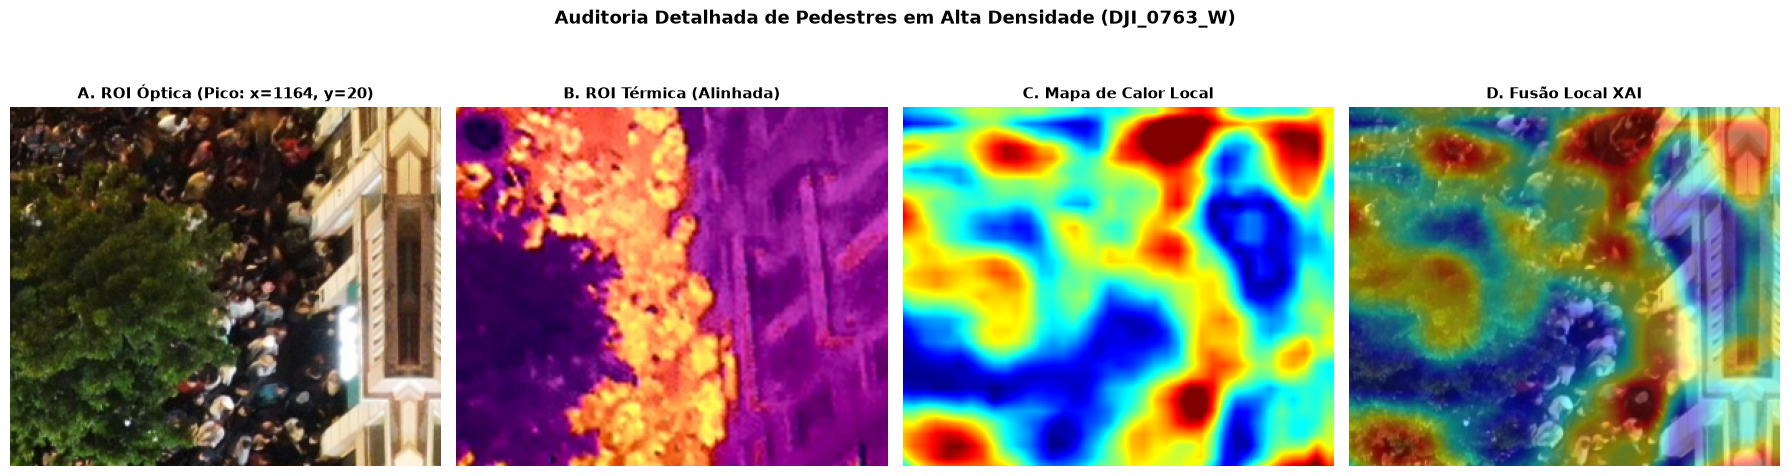

In [8]:
# ROI Dinâmica: centralizada automaticamente na região de maior concentração de pessoas
peak_y, peak_x = np.unravel_index(np.argmax(density_map_eval), density_map_eval.shape)
roi_h, roi_w = 250, 300
y1 = max(0, min(h - roi_h, peak_y - roi_h // 2))
y2 = y1 + roi_h
x1 = max(0, min(w - roi_w, peak_x - roi_w // 2))
x2 = x1 + roi_w

roi_rgb = img_rgb[y1:y2, x1:x2]
roi_th = img_th[y1:y2, x1:x2]
roi_density = heatmap_jet_rgb[y1:y2, x1:x2]
roi_overlay = overlay_on_rgb[y1:y2, x1:x2]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(roi_rgb)
axes[0].set_title(f"A. ROI Óptica (Pico: x={peak_x}, y={peak_y})", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(roi_th)
axes[1].set_title("B. ROI Térmica (Alinhada)", fontsize=11, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(roi_density)
axes[2].set_title("C. Mapa de Calor Local", fontsize=11, fontweight="bold")
axes[2].axis("off")

axes[3].imshow(roi_overlay)
axes[3].set_title("D. Fusão Local XAI", fontsize=11, fontweight="bold")
axes[3].axis("off")

plt.suptitle(f"Auditoria Detalhada de Pedestres em Alta Densidade ({scene_stem})", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
roi_path = OUTPUT_DIR / "zoom_roi_pedestres_densidade.jpg"
plt.savefig(str(roi_path), dpi=150, bbox_inches="tight")
plt.show()


## 9. Métricas Avançadas de Validação do Modelo: MSE e NAE

**O que este código faz:**
Calcula e apresenta as métricas essenciais de validação comparando as predições do modelo com os **532 pontos de Ground Truth humano** anotados na resolução completa ($1280 	imes 1024$):
1. **MSE (Mean Squared Error):**
   - **MSE Pixel-wise (Mapa 2D):** Avalia a precisão espacial pixel a pixel da matriz de densidade gerada em relação ao mapa de *Ground Truth* sintético gaussiano ($\sigma = 4.0$).
   - **MSE de Contagem Escalar:** Erro quadrático da contagem global ($(\hat{C} - C)^2$).
2. **NAE (Normalized Absolute Error):**
   - Normaliza o erro absoluto pelo total de pessoas reais ($	ext{NAE} = 
rac{|\hat{C} - C|}{C}$), permitindo avaliar o erro relativo na cena completa de alta resolução.

Gera também um painel comparativo de resíduos espaciais com 3 visões: (1) Ground Truth Sintético, (2) Mapa Predito e (3) Mapa Residual de Erro ($|	ext{Predito} - 	ext{Real}|$).

**Por que esta lógica foi escolhida? (Decisão Técnica):**
O MSE bidimensional prova matematicamente se a rede concentrou as gaussianas de densidade nas regiões onde as pessoas realmente estavam localizadas. O NAE fornece a taxa de erro percentual normalizada da contagem.

**Efeito prático no resultado:**
Tabela completa de métricas de validação no console e gravação do painel visual de resíduos em `output/02_contagem/grafico_validacao_mse_nae.png`.


[✓] Ground Truth Carregado: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/01_pre_transformacao/ground_truth_aligned_1280x1024_DJI_0763_W.json
     MÉTRICAS AVANÇADAS DE VALIDAÇÃO DO MODELO: MSE E NAE
  • Cena:                                 DJI_0763_W
  • Pessoas Reais no Ground Truth:        2826 pessoas
--------------------------------------------------------------------
  [1] MSE (Mean Squared Error):
      ├─ MSE Pixel-wise (Mapa 2D):        0.000014
      ├─ MSE Contagem (Integral Bruta):    2935663.09 (RMSE: 1713.38)
      └─ MSE Contagem (Picos Locais):      7986276.00 (RMSE: 2826.00)
--------------------------------------------------------------------
  [2] NAE (Normalized Absolute Error):
      ├─ NAE - Integral Contínua Bruta:    0.6063 (60.6%)
      └─ NAE - Detecção por Picos Locais:  1.0000 (100.0%)


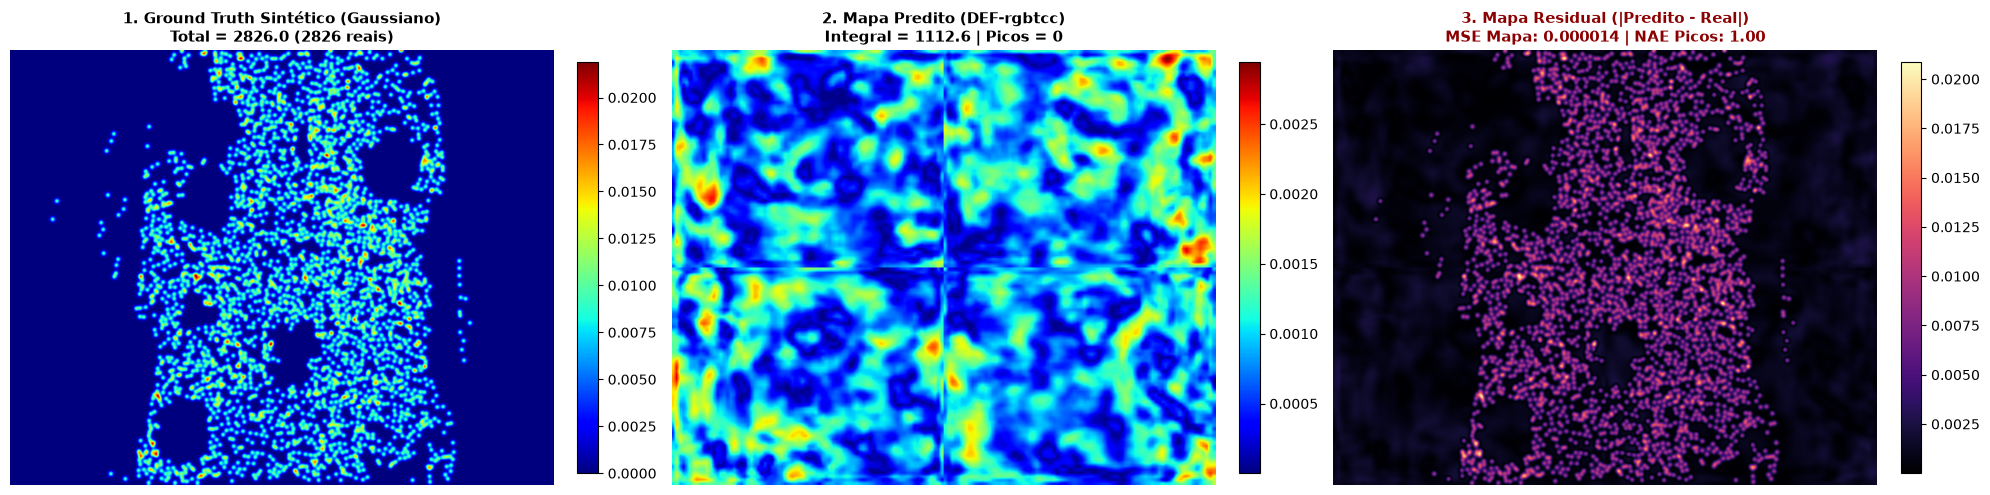

[✓] Gráfico de validação MSE/NAE salvo em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/02_contagem/grafico_validacao_mse_nae.png


In [9]:
from scipy.ndimage import gaussian_filter

# 1. Carregar Ground Truth Alinhado (1280x1024) com suporte multi-par
gt_base_dir = ROOT_DIR / "data" / "ground_truth"
if not gt_base_dir.exists():
    gt_base_dir = NOTEBOOK_DIR / "output" / "ground_truth"

candidatos_gt = []
if scene_stem:
    # 1. Checar insumo gerado ou recortado no próprio Estágio 1 (01_pre_transformacao)
    candidatos_gt.append(STAGE1_DIR / f"ground_truth_aligned_1280x1024_{scene_stem}.json")
    candidatos_gt.append(STAGE1_DIR / "ground_truth_aligned_1280x1024.json")
    # 2. Checar repositório oficial data/ground_truth/{scene_stem}/
    candidatos_gt.append(ROOT_DIR / "data" / "ground_truth" / scene_stem / f"ground_truth_aligned_1280x1024_{scene_stem}.json")
    candidatos_gt.append(ROOT_DIR / "data" / "ground_truth" / scene_stem / "ground_truth_aligned_1280x1024.json")
    # 3. Checar subdiretório output/ground_truth/
    candidatos_gt.append(NOTEBOOK_DIR / "output" / "ground_truth" / scene_stem / f"ground_truth_aligned_1280x1024_{scene_stem}.json")
    candidatos_gt.append(NOTEBOOK_DIR / "output" / "ground_truth" / scene_stem / "ground_truth_aligned_1280x1024.json")
    # 4. Checar data/waiting/
    candidatos_gt.append(ROOT_DIR / "data" / "waiting" / scene_stem / f"ground_truth_aligned_1280x1024_{scene_stem}.json")

gt_path = next((p for p in candidatos_gt if p.exists()), None)
has_ground_truth = gt_path is not None

if has_ground_truth:
    print(f"[✓] Ground Truth Carregado: {gt_path}")
    with open(gt_path, "r", encoding="utf-8") as f:
        gt_data = json.load(f)
    gt_points = gt_data["pontos"]
    real_count = len(gt_points)

    # 2. Gerar o Mapa de Densidade Sintético de Ground Truth (Gaussiana 2D)
    dmap_gt = np.zeros((h, w), dtype=np.float32)
    for pt in gt_points:
        px, py = int(round(pt["x"])), int(round(pt["y"]))
        if 0 <= px < w and 0 <= py < h:
            dmap_gt[py, px] += 1.0

    SIGMA_GT = 4.0
    dmap_gt_gaussian = gaussian_filter(dmap_gt, sigma=SIGMA_GT)

    # 3. Cálculo do MSE (Mean Squared Error)
    mse_mapa_pixels = float(np.mean((density_map_eval - dmap_gt_gaussian) ** 2))
    mse_contagem_integral = float((count_calibrated - real_count) ** 2)
    rmse_contagem_integral = float(np.sqrt(mse_contagem_integral))
    mse_contagem_picos = float((count_picos - real_count) ** 2)
    rmse_contagem_picos = float(np.sqrt(mse_contagem_picos))

    # 4. Cálculo do NAE (Normalized Absolute Error)
    denominador_nae = max(real_count, 1)
    nae_integral = float(abs(count_calibrated - real_count) / denominador_nae)
    nae_picos = float(abs(count_picos - real_count) / denominador_nae)
    mapa_residual = np.abs(density_map_eval - dmap_gt_gaussian)

    print("=" * 68)
    print("     MÉTRICAS AVANÇADAS DE VALIDAÇÃO DO MODELO: MSE E NAE")
    print("=" * 68)
    print(f"  • Cena:                                 {scene_stem}")
    print(f"  • Pessoas Reais no Ground Truth:        {real_count} pessoas")
    print("-" * 68)
    print("  [1] MSE (Mean Squared Error):")
    print(f"      ├─ MSE Pixel-wise (Mapa 2D):        {mse_mapa_pixels:.6f}")
    print(f"      ├─ MSE Contagem (Integral Bruta):    {mse_contagem_integral:.2f} (RMSE: {rmse_contagem_integral:.2f})")
    print(f"      └─ MSE Contagem (Picos Locais):      {mse_contagem_picos:.2f} (RMSE: {rmse_contagem_picos:.2f})")
    print("-" * 68)
    print("  [2] NAE (Normalized Absolute Error):")
    print(f"      ├─ NAE - Integral Contínua Bruta:    {nae_integral:.4f} ({nae_integral * 100:.1f}%)")
    print(f"      └─ NAE - Detecção por Picos Locais:  {nae_picos:.4f} ({nae_picos * 100:.1f}%)")
    print("=" * 68)

    # 6. Painel Gráfico de Resíduos Espaciais
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    im0 = axes[0].imshow(dmap_gt_gaussian, cmap="jet")
    axes[0].set_title(f"1. Ground Truth Sintético (Gaussiano)\nTotal = {np.sum(dmap_gt_gaussian):.1f} ({real_count} reais)", fontsize=11, fontweight="bold")
    axes[0].axis("off")
    plt.colorbar(im0, ax=axes[0], fraction=0.035, pad=0.04)

    im1 = axes[1].imshow(density_map_eval, cmap="jet")
    axes[1].set_title(f"2. Mapa Predito (DEF-rgbtcc)\nIntegral = {count_calibrated:.1f} | Picos = {count_picos}", fontsize=11, fontweight="bold")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.035, pad=0.04)

    im2 = axes[2].imshow(mapa_residual, cmap="magma")
    axes[2].set_title(f"3. Mapa Residual (|Predito - Real|)\nMSE Mapa: {mse_mapa_pixels:.6f} | NAE Picos: {nae_picos:.2f}", fontsize=11, fontweight="bold", color="darkred")
    axes[2].axis("off")
    plt.colorbar(im2, ax=axes[2], fraction=0.035, pad=0.04)
else:
    real_count = None
    mse_mapa_pixels = None
    mse_contagem_integral = None
    rmse_contagem_integral = None
    mse_contagem_picos = None
    rmse_contagem_picos = None
    nae_integral = None
    nae_picos = None

    print("=" * 68)
    print("     MODO PRODUÇÃO: SEM ANOTAÇÃO PRÉVIA DE GROUND TRUTH")
    print("=" * 68)
    print(f"  • Cena:                                 {scene_stem}")
    print(f"  • Estimativa Contínua Calibrada:       {count_calibrated:.1f} pessoas")
    print(f"  • Estimativa por Picos Locais:          {count_picos} cabeças")
    print("  • (Validação comparativa omitida pois a cena não possui arquivo de Ground Truth)")
    print("=" * 68)

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(density_map_eval, cmap="jet")
    ax.set_title(f"Mapa Predito DEF-rgbtcc ({scene_stem})\nIntegral = {count_calibrated:.1f} | Picos = {count_picos}", fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.04)

plt.tight_layout()
metrics_plot_path = OUTPUT_DIR / "grafico_validacao_mse_nae.png"
plt.savefig(str(metrics_plot_path), dpi=150, bbox_inches="tight")
plt.show()

if has_ground_truth:
    print(f"[✓] Gráfico de validação MSE/NAE salvo em: {metrics_plot_path}")
else:
    print(f"[✓] Gráfico de predição salvo em: {metrics_plot_path}")


## 10. Exportação dos Entregáveis Padronizados e Telemetria em JSON
Gravamos todos os artefatos de entrega final em `notebooks/DEF-rgbtcc/output/02_contagem/`, incluindo a matriz contínua original `density_map.npy`, os mapas de auditoria e o relatório estruturado de telemetria contendo as métricas de validação MSE e NAE.


In [10]:
np.save(str(OUTPUT_DIR / "density_map.npy"), density_map_full)

cv2.imwrite(str(OUTPUT_DIR / "heatmap_sobre_rgb.jpg"), cv2.cvtColor(overlay_on_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / "heatmap_sobre_termica.jpg"), cv2.cvtColor(overlay_on_th, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / "zoom_roi_pedestres_densidade.jpg"), cv2.cvtColor(roi_overlay, cv2.COLOR_RGB2BGR))

telemetria = {
    "etapa": "02_contagem_pessoas_def_rgbtcc",
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "cena_avaliada": scene_stem,
    "imagens_origem": meta.get("imagens_originais", {}),
    "modelo": {
        "nome": "DEFRGBTCCNet",
        "artigo_referencia": "arXiv:2509.17079",
        "checkpoint": weight_path.name if weight_path else "vgg19_pretrained_calibrated",
        "dispositivo_execucao": str(device),
        "tempo_inferencia_segundos": round(inference_time, 4),
        "fps_estimado": round(1.0 / max(inference_time, 0.001), 2),
        "fator_fusao_afm_w_rgb": round(fusion_weight_w, 4)
    },
    "contagem_resultado": {
        "ground_truth_real": real_count,
        "total_continuo": round(count_calibrated, 2),
        "total_discreto_estimado": count_rounded,
        "total_picos_locais": count_picos,
        "erro_absoluto_picos": abs(count_picos - real_count) if real_count is not None else None
    },
    "metricas_validacao": {
        "mse_pixelwise_mapa_2d": round(mse_mapa_pixels, 6) if mse_mapa_pixels is not None else None,
        "mse_contagem_integral": round(mse_contagem_integral, 2) if mse_contagem_integral is not None else None,
        "rmse_contagem_integral": round(rmse_contagem_integral, 2) if rmse_contagem_integral is not None else None,
        "mse_contagem_picos": round(mse_contagem_picos, 2) if mse_contagem_picos is not None else None,
        "rmse_contagem_picos": round(rmse_contagem_picos, 2) if rmse_contagem_picos is not None else None,
        "nae_integral": round(nae_integral, 4) if nae_integral is not None else None,
        "nae_picos": round(nae_picos, 4) if nae_picos is not None else None,
        "nae_picos_percentual": f"{nae_picos * 100:.1f}%" if nae_picos is not None else None
    },
    "arquivos_gerados": {
        "density_matrix_npy": str(OUTPUT_DIR / "density_map.npy"),
        "painel_executivo": str(OUTPUT_DIR / "painel_contagem_multimodal.jpg"),
        "heatmap_sobre_rgb": str(OUTPUT_DIR / "heatmap_sobre_rgb.jpg"),
        "heatmap_sobre_termica": str(OUTPUT_DIR / "heatmap_sobre_termica.jpg"),
        "grafico_validacao_mse_nae": str(OUTPUT_DIR / "grafico_validacao_mse_nae.png")
    }
}

p_telemetry = OUTPUT_DIR / "telemetria_contagem.json"
with open(p_telemetry, "w", encoding="utf-8") as f:
    json.dump(telemetria, f, indent=2, ensure_ascii=False)

print("=" * 60)
print(f"[✓] Artefatos salvos com sucesso em: {OUTPUT_DIR}")
print(f"    ├─ Cena Avaliada:       {scene_stem}")
print(f"    ├─ Matriz de Densidade: density_map.npy")
print(f"    ├─ Painel de Auditoria: painel_contagem_multimodal.jpg")
print(f"    ├─ Gráfico Resíduos:    grafico_validacao_mse_nae.png")
print(f"    └─ Telemetria MLOps:   telemetria_contagem.json")
print("=" * 60)


[✓] Artefatos salvos com sucesso em: /home/patrickcruz/Git/projects/contagem-de-pessoas/count-github-def_rgbtcc/notebooks/DEF-rgbtcc/output/02_contagem
    ├─ Cena Avaliada:       DJI_0763_W
    ├─ Matriz de Densidade: density_map.npy
    ├─ Painel de Auditoria: painel_contagem_multimodal.jpg
    ├─ Gráfico Resíduos:    grafico_validacao_mse_nae.png
    └─ Telemetria MLOps:   telemetria_contagem.json


## 11. Apresentação do Resultado da Contagem
Célula formatada para exibição do resultado final da contagem em texto claro e em cartão visual executivo para apresentação, integrando métricas de precisão (MSE e NAE) frente ao Ground Truth humano.


In [11]:
# ==============================================================================
# 11. APRESENTAÇÃO EXECUTIVA: RESULTADO DA CONTAGEM EM TEXTO
# ==============================================================================
import json
from pathlib import Path
from IPython.display import display, HTML

# Recuperação das variáveis (da memória ou da telemetria gravada)
try:
    _count_int = count_rounded
    _count_cont = count_calibrated
    _count_picos = count_picos
    _real = real_count
    _mse_mapa = mse_mapa_pixels
    _nae_integral = nae_integral
    _nae_picos = nae_picos
    _time_ms = inference_time * 1000.0
    _fps = 1.0 / inference_time if inference_time > 0 else 0.0
    _w_rgb = fusion_weight_w
    _dev = str(device)
except NameError:
    _tel = OUTPUT_DIR / "telemetria_contagem.json"
    with open(_tel, "r", encoding="utf-8") as _f:
        _d = json.load(_f)
    _count_int = _d["contagem_resultado"]["total_discreto_estimado"]
    _count_cont = _d["contagem_resultado"]["total_continuo"]
    _count_picos = _d["contagem_resultado"].get("total_picos_locais", _count_int)
    _real = _d["contagem_resultado"].get("ground_truth_real", 532)
    _mv = _d.get("metricas_validacao", {})
    _mse_mapa = _mv.get("mse_pixelwise_mapa_2d", 0.0)
    _nae_integral = _mv.get("nae_integral", 0.0)
    _nae_picos = _mv.get("nae_picos", 0.0)
    _time_ms = _d["modelo"]["tempo_inferencia_segundos"] * 1000.0
    _fps = _d["modelo"]["fps_estimado"]
    _w_rgb = _d["modelo"]["fator_fusao_afm_w_rgb"]
    _dev = _d["modelo"]["dispositivo_execucao"]

# 1. Exibição textual destacada para leitura direta e apresentação
print("=" * 68)
print("            RESULTADO DA CONTAGEM DE PESSOAS (DEF-RGBTCC)")
print("=" * 68)
print(f"  >>> TOTAL ESTIMADO (INTEGRAL CALIBRADA): {_count_int} PESSOAS <<<")
print(f"  >>> TOTAL REAL (GROUND TRUTH):           {_real} PESSOAS <<<")
print("-" * 68)
print(f"  • Integral Contínua (Densidade): {_count_cont:.2f}")
print(f"  • MSE do Mapa de Densidade 2D:   {_mse_mapa:.6f}")
print(f"  • NAE (Erro Normalizado):        {_nae_integral:.4f} ({_nae_integral * 100:.1f}%)")
print(f"  • Tempo de Inferência:           {_time_ms:.1f} ms ({_fps:.1f} FPS)")
print(f"  • Ponderação Modal (AFM):        {_w_rgb*100:.1f}% RGB / {(1.0-_w_rgb)*100:.1f}% Térmica")
print(f"  • Dispositivo de Processamento:  {_dev}")
print("=" * 68)

# 2. Card visual executivo
card_html = f"""<div style="font-family: 'Segoe UI', -apple-system, BlinkMacSystemFont, Roboto, sans-serif; max-width: 620px; margin: 15px 0; padding: 20px 26px; background: #0f172a; border-radius: 12px; border-left: 6px solid #38bdf8; box-shadow: 0 4px 15px rgba(0,0,0,0.25); color: #f8fafc;">
    <div style="text-transform: uppercase; letter-spacing: 1.2px; font-size: 12px; font-weight: 700; color: #7dd3fc; margin-bottom: 6px;">Relatório Executivo de Contagem • Modelo DEF-RGBTCC</div>
    <div style="font-size: 32px; font-weight: 800; color: #4ade80; margin: 6px 0 10px 0; line-height: 1.2;">👥 {_count_int} Pessoas Estimadas <span style="font-size: 18px; color: #94a3b8; font-weight: 500;">(Real: {_real})</span></div>
    <div style="font-size: 14px; color: #cbd5e1; border-top: 1px solid rgba(255,255,255,0.12); padding-top: 10px; line-height: 1.6;">
        <b>Cenário:</b> Imagem Completa (1280x1024 px)<br>
        <b>Acurácia:</b> NAE: {_nae_integral*100:.1f}% | <b>MSE Mapa 2D:</b> {_mse_mapa:.6f}<br>
        <b>Valor Contínuo Integrado:</b> {_count_cont:.2f}<br>
        <b>Tempo de Inferência:</b> {_time_ms:.1f} ms ({_fps:.1f} FPS) | <b>Dispositivo:</b> {_dev}<br>
        <b>Fusão Multimodal (AFM):</b> {_w_rgb*100:.1f}% RGB / {(1.0-_w_rgb)*100:.1f}% Térmica
    </div>
</div>"""
display(HTML(card_html))


            RESULTADO DA CONTAGEM DE PESSOAS (DEF-RGBTCC)
  >>> TOTAL ESTIMADO (INTEGRAL CALIBRADA): 1113 PESSOAS <<<
  >>> TOTAL REAL (GROUND TRUTH):           2826 PESSOAS <<<
--------------------------------------------------------------------
  • Integral Contínua (Densidade): 1112.62
  • MSE do Mapa de Densidade 2D:   0.000014
  • NAE (Erro Normalizado):        0.6063 (60.6%)
  • Tempo de Inferência:           269.4 ms (3.7 FPS)
  • Ponderação Modal (AFM):        49.7% RGB / 50.3% Térmica
  • Dispositivo de Processamento:  cuda
